# **Import Libraries and Setup**

In [ ]:
#Import necessary libraries
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import kagglehub
import shutil
from PIL import Image
import torch.nn.functional as F
import torch.cuda.amp as amp
import random
# Sets a starting point for random number generation
torch.manual_seed(42)
np.random.seed(42)
# Checks if a GPU is available otherwise, it uses the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


# **Download Dataset from KaggleHub**

In [ ]:
# Downloads a skin disease dataset from Kaggle and stores it in a folder
os.environ["KAGGLEHUB_CACHE"] = "/content/data"
path = kagglehub.dataset_download("pacificrm/skindiseasedataset")

print("Path to dataset files:", path)
print("Downloaded dataset contents:", os.listdir(path))

Path to dataset files: /kaggle/input/skindiseasedataset
Downloaded dataset contents: ['SkinDisease', 'Readme.md']


# **Filter and Copy Selected Classes**

In [ ]:
# Defines dataset paths to train and test folders and folders for filtered data
source_train_dir = os.path.join(path, "SkinDisease/SkinDisease/train")
source_test_dir = os.path.join(path, "SkinDisease/SkinDisease/test")
target_train_dir = "/content/filtered_dataset/train"
target_test_dir = "/content/filtered_dataset/test"

print("Source train dir contents:", os.listdir(source_train_dir))
print("Source test dir contents:", os.listdir(source_test_dir))
# Copies  the selected classes from the original dataset to new folders
selected_classes = ["Psoriasis", "Tinea", "Rosacea", "Eczema", "Acne", "Seborrh_Keratoses", "Warts", "Unknown_Normal"]

def filter_classes(source_dir, target_dir, classes):
    os.makedirs(target_dir, exist_ok=True)
    for class_name in classes:
        src_path = os.path.join(source_dir, class_name)
        dst_path = os.path.join(target_dir, class_name)
        if os.path.exists(src_path):
            shutil.copytree(src_path, dst_path, dirs_exist_ok=True)
            print(f"Copied {class_name}")
        else:
            print(f"Class {class_name} not found")

filter_classes(source_train_dir, target_train_dir, selected_classes)
filter_classes(source_test_dir, target_test_dir, selected_classes)


Source train dir contents: ['Benign_tumors', 'Unknown_Normal', 'Tinea', 'Eczema', 'Actinic_Keratosis', 'Vascular_Tumors', 'Acne', 'Infestations_Bites', 'Rosacea', 'Seborrh_Keratoses', 'Moles', 'Vitiligo', 'SkinCancer', 'Vasculitis', 'Lichen', 'Candidiasis', 'DrugEruption', 'Sun_Sunlight_Damage', 'Bullous', 'Warts', 'Psoriasis', 'Lupus']
Source test dir contents: ['Benign_tumors', 'Unknown_Normal', 'Tinea', 'Eczema', 'Actinic_Keratosis', 'Vascular_Tumors', 'Acne', 'Infestations_Bites', 'Rosacea', 'Seborrh_Keratoses', 'Moles', 'Vitiligo', 'SkinCancer', 'Vasculitis', 'Lichen', 'Candidiasis', 'DrugEruption', 'Sun_Sunlight_Damage', 'Bullous', 'Warts', 'Psoriasis', 'Lupus']
Copied Psoriasis
Copied Tinea
Copied Rosacea
Copied Eczema
Copied Acne
Copied Seborrh_Keratoses
Copied Warts
Copied Unknown_Normal
Copied Psoriasis
Copied Tinea
Copied Rosacea
Copied Eczema
Copied Acne
Copied Seborrh_Keratoses
Copied Warts
Copied Unknown_Normal


# **EDA on Dataset**

Filtered Dataset: Counter({6: 1651, 1: 1010, 5: 923, 2: 820, 0: 593, 7: 580, 4: 455, 3: 254})


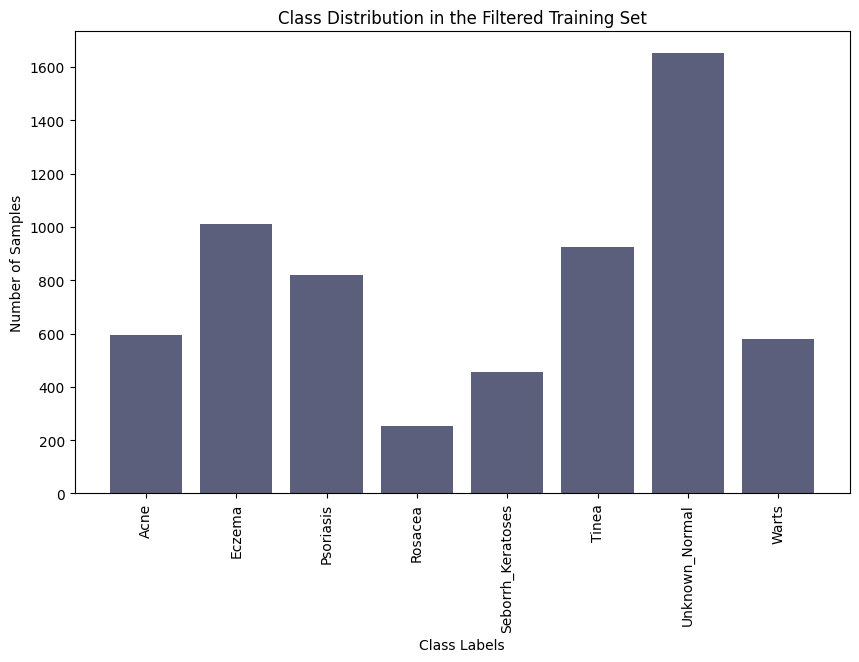

In [ ]:
# Explore class distribution in a dataset directory
def explore_data(directory):
    class_names = sorted(os.listdir(directory))
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
    labels = []
    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):
            labels.extend([class_to_idx[class_name]] * len(os.listdir(class_dir)))
    print(f"Filtered Dataset: {Counter(labels)}")
    return labels, class_names

train_labels, class_names = explore_data(target_train_dir)

plt.figure(figsize=(10, 6))
plt.bar(class_names, [train_labels.count(i) for i in range(len(class_names))], color='#5c5f7c')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in the Filtered Training Set')
plt.xticks(rotation=90)
plt.show()

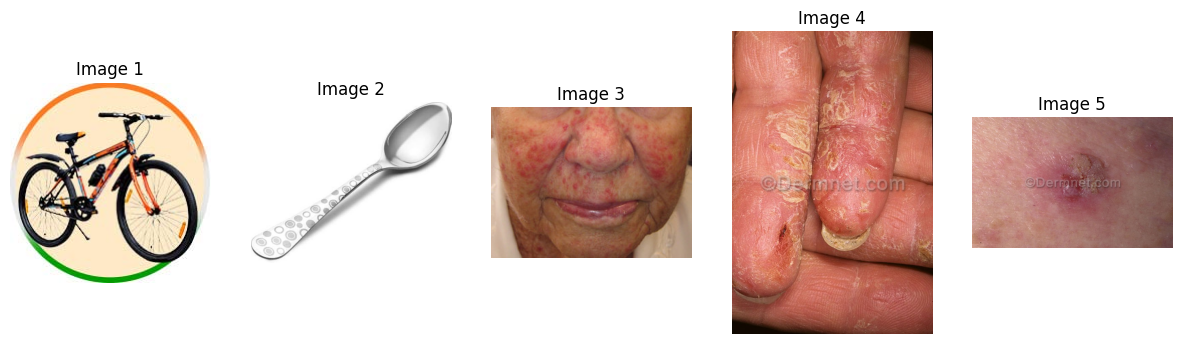

In [ ]:
def show_random_samples_from_data(directory, num_samples=5):
    plt.figure(figsize=(15, 15))
    all_images = []
    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):
            all_images.extend([os.path.join(class_dir, img) for img in os.listdir(class_dir)])
    random_images = random.sample(all_images, num_samples)
    for i, img_path in enumerate(random_images):
        img = Image.open(img_path)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Image {i+1}")
        plt.axis('off')
    plt.show()

show_random_samples_from_data(target_train_dir)

# **Define Custom Dataset Class**

In [ ]:
# Defines a custom SkinDiseaseDataset class to load and preprocess images in this code
class SkinDiseaseDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = sorted(os.listdir(directory))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

        for class_name in self.class_names:
            class_dir = os.path.join(directory, class_name)
            if not os.path.isdir(class_dir):
                continue
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                self.images.append(img_path)
                self.labels.append(self.class_to_idx[class_name])

        print(f"Dataset {directory}: {Counter(self.labels)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# **Define Data Transforms**

In [ ]:
# Images preprocessed for training and testing
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=0.1),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = SkinDiseaseDataset(target_train_dir, transform=train_transforms)
test_dataset = SkinDiseaseDataset(target_test_dir, transform=test_transforms)

Dataset /content/filtered_dataset/train: Counter({6: 1651, 1: 1010, 5: 923, 2: 820, 0: 593, 7: 580, 4: 455, 3: 254})
Dataset /content/filtered_dataset/test: Counter({6: 189, 1: 112, 5: 102, 2: 88, 0: 65, 7: 64, 4: 51, 3: 28})


# **Create DataLoaders**

In [ ]:
#
num_workers = 8
try:
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=num_workers, pin_memory=True)
except RuntimeError:
    print("DataLoader failed with num_workers=8, falling back to num_workers=2")
    num_workers = 2
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=num_workers, pin_memory=True)

# **Define StyleGAN Generator and Discriminator**

In [ ]:
# Define the generator and Discriminator for the GAN
def get_noise(batch_size, noise_dim, device):
    return torch.randn(batch_size, noise_dim, device=device)

def get_style_vector(noise, mapping_network):
    return mapping_network(noise)

class AdaIN(nn.Module):
    def __init__(self, channels, style_dim):
        super(AdaIN, self).__init__()
        self.norm = nn.InstanceNorm2d(channels, affine=False)
        self.style_scale = nn.Linear(style_dim, channels)
        self.style_shift = nn.Linear(style_dim, channels)

    def forward(self, x, style):
        batch, channels, _, _ = x.size()
        scale = self.style_scale(style).view(batch, channels, 1, 1)
        shift = self.style_shift(style).view(batch, channels, 1, 1)
        normalized = self.norm(x)
        return scale * normalized + shift

class StyleGANGeneratorBlock(nn.Module):
    def __init__(self, in_channels, out_channels, style_dim, upsample=True):
        super(StyleGANGeneratorBlock, self).__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear') if upsample else nn.Identity()
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.adain = AdaIN(out_channels, style_dim)
        self.lrelu = nn.LeakyReLU(0.2)

    def forward(self, x, style):
        x = self.upsample(x)
        x = self.conv(x)
        x = self.adain(x, style)
        x = self.lrelu(x)
        return x

class StyleGANGenerator(nn.Module):
    def __init__(self, num_classes, noise_dim=128, style_dim=128, base_channels=256):
        super(StyleGANGenerator, self).__init__()
        self.noise_dim = noise_dim
        self.style_dim = style_dim
        self.num_classes = num_classes
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.mapping_network = nn.Sequential(
            nn.Linear(noise_dim + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, style_dim)
        )
        self.initial_constant = nn.Parameter(torch.randn(1, base_channels, 4, 4))
        self.blocks = nn.ModuleList([
            StyleGANGeneratorBlock(base_channels, base_channels // 2, style_dim),
            StyleGANGeneratorBlock(base_channels // 2, base_channels // 4, style_dim),
            StyleGANGeneratorBlock(base_channels // 4, base_channels // 8, style_dim),
            StyleGANGeneratorBlock(base_channels // 8, base_channels // 16, style_dim),
            StyleGANGeneratorBlock(base_channels // 16, base_channels // 32, style_dim),
        ])
        self.to_rgb = nn.Conv2d(base_channels // 32, 3, 1)
        self.tanh = nn.Tanh()

    def forward(self, noise, labels):
        label_emb = self.label_emb(labels)
        z = torch.cat([noise, label_emb], dim=1)
        style = self.mapping_network(z)
        x = self.initial_constant.repeat(noise.size(0), 1, 1, 1)
        for block in self.blocks:
            x = block(x, style)
        x = self.to_rgb(x)
        x = self.tanh(x)
        return x

class StyleGANDiscriminator(nn.Module):
    def __init__(self, num_classes, base_channels=32):
        super(StyleGANDiscriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Conv2d(3 + num_classes, base_channels, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(base_channels, base_channels * 2, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(base_channels * 2, base_channels * 4, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(base_channels * 4, base_channels * 8, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(base_channels * 8, base_channels * 16, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(base_channels * 16 * 4 * 4, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )

    def forward(self, x, labels):
        label_emb = self.label_emb(labels)
        label_emb = label_emb.view(label_emb.size(0), label_emb.size(1), 1, 1)
        label_emb = label_emb.repeat(1, 1, x.size(2), x.size(3))
        x = torch.cat([x, label_emb], dim=1)
        return self.model(x)


# **Train StyleGAN Model**

In [ ]:
# Trining the GAN
def train_stylegan(generator, discriminator, train_loader, device, epochs=50, batch_size=128):
    criterion = nn.BCEWithLogitsLoss()
    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.0, 0.99))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.0, 0.99))
    scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')

    half_batch = batch_size // 2

    for epoch in range(epochs):
        for real_imgs, labels in train_loader:
            real_imgs, labels = real_imgs.to(device), labels.to(device)
            batch_size = real_imgs.size(0)
            half_batch = min(half_batch, batch_size // 2)
            if half_batch == 0:
                continue

            with torch.amp.autocast('cuda', enabled=device.type == 'cuda'):
                d_optimizer.zero_grad()
                real_labels = torch.ones(half_batch, 1, device=device) * 0.9
                noise = torch.randn(half_batch, generator.noise_dim, device=device)
                fake_imgs = generator(noise, labels[:half_batch])
                fake_labels = torch.zeros(half_batch, 1, device=device)

                d_real_loss = criterion(discriminator(real_imgs[:half_batch], labels[:half_batch]), real_labels)
                d_fake_loss = criterion(discriminator(fake_imgs, labels[:half_batch]), fake_labels)
                d_loss = (d_real_loss + d_fake_loss) / 2

            scaler.scale(d_loss).backward()
            scaler.step(d_optimizer)

            with torch.amp.autocast('cuda', enabled=device.type == 'cuda'):
                g_optimizer.zero_grad()
                noise = torch.randn(batch_size, generator.noise_dim, device=device)
                fake_imgs = generator(noise, labels)
                g_labels = torch.ones(batch_size, 1, device=device)
                g_loss = criterion(discriminator(fake_imgs, labels), g_labels)

            scaler.scale(g_loss).backward()
            scaler.step(g_optimizer)
            scaler.update()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

generator = StyleGANGenerator(num_classes=len(selected_classes)).to(device)
discriminator = StyleGANDiscriminator(num_classes=len(selected_classes)).to(device)
train_stylegan(generator, discriminator, train_loader, device, epochs=200, batch_size=128)

Epoch 0/200, D Loss: 0.7017, G Loss: 0.8396
Epoch 10/200, D Loss: 0.6874, G Loss: 0.8025
Epoch 20/200, D Loss: 0.6959, G Loss: 0.8013
Epoch 30/200, D Loss: 0.6509, G Loss: 0.9710
Epoch 40/200, D Loss: 0.6498, G Loss: 0.9850
Epoch 50/200, D Loss: 0.6755, G Loss: 1.2754
Epoch 60/200, D Loss: 0.5644, G Loss: 1.2805
Epoch 70/200, D Loss: 0.5595, G Loss: 1.9850
Epoch 80/200, D Loss: 0.5522, G Loss: 1.2591
Epoch 90/200, D Loss: 0.4692, G Loss: 1.2722
Epoch 100/200, D Loss: 0.5579, G Loss: 3.0001
Epoch 110/200, D Loss: 0.3890, G Loss: 1.9992
Epoch 120/200, D Loss: 0.3990, G Loss: 2.3199
Epoch 130/200, D Loss: 0.3690, G Loss: 2.9677
Epoch 140/200, D Loss: 0.4468, G Loss: 2.2128
Epoch 150/200, D Loss: 0.3212, G Loss: 2.4267
Epoch 160/200, D Loss: 0.3486, G Loss: 2.3483
Epoch 170/200, D Loss: 0.3608, G Loss: 2.5482
Epoch 180/200, D Loss: 0.3287, G Loss: 2.7045
Epoch 190/200, D Loss: 0.3853, G Loss: 2.3220


# **Generate Synthetic Images**

In [ ]:
# Generate synthetic images to balance dataset
def generate_synthetic_images(generator, num_classes, device, class_counts):
    synthetic_images = []
    synthetic_labels = []
    generator.eval()
    with torch.no_grad():
        for class_idx in range(num_classes):
            target_samples = 1200
            current_samples = class_counts[class_idx]
            num_images = target_samples - current_samples if target_samples > current_samples else 0
            if num_images <= 0:
                continue
            noise = torch.randn(num_images, generator.noise_dim, device=device)
            labels = torch.full((num_images,), class_idx, dtype=torch.long, device=device)
            imgs = generator(noise, labels)
            imgs = (imgs + 1) / 2
            if num_images > 0:
                num_to_show = min(4, num_images)
                plt.figure(figsize=(12, 3))
                for i in range(num_to_show):
                    plt.subplot(1, num_to_show, i + 1)
                    img = imgs[i].cpu().numpy().transpose(1, 2, 0)
                    plt.imshow(img)
                    plt.title(f"Class {class_idx}")
                    plt.axis('off')
                plt.show()
            synthetic_images.append(imgs.cpu().numpy())
            synthetic_labels.extend([class_idx] * num_images)
    synthetic_images = np.concatenate(synthetic_images, axis=0) if synthetic_images else np.array([])
    synthetic_labels = np.array(synthetic_labels)
    return synthetic_images, synthetic_labels

# **Combine Datasets and Prepare for CNN Training**

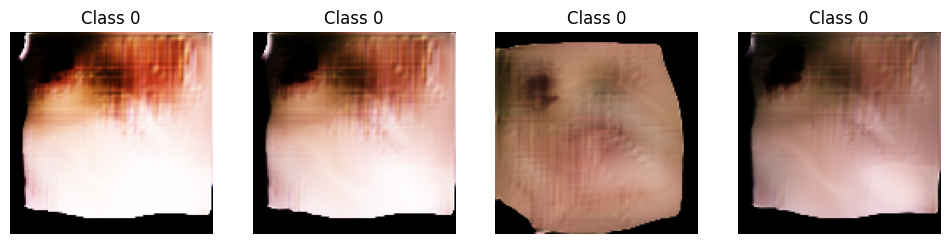

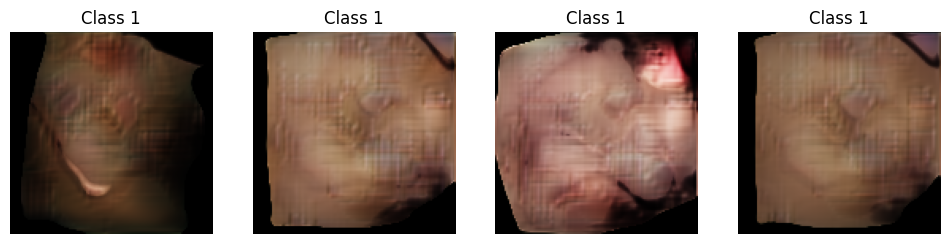

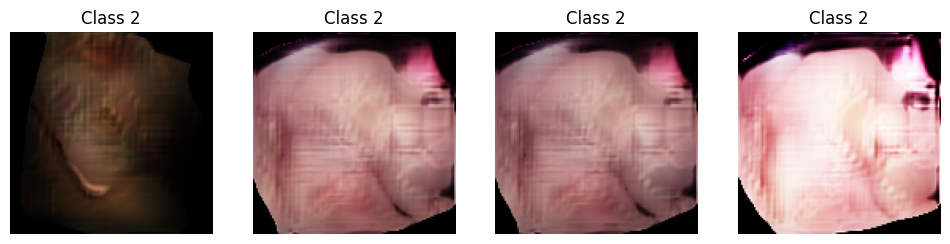

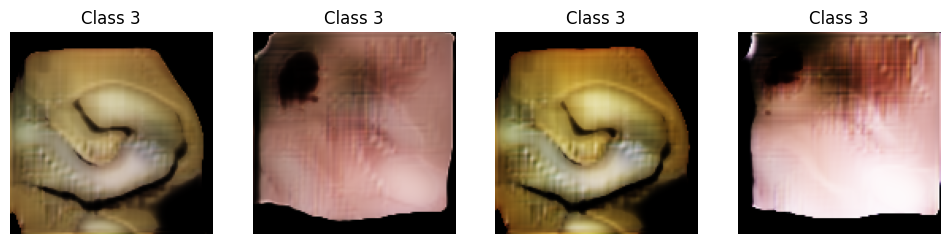

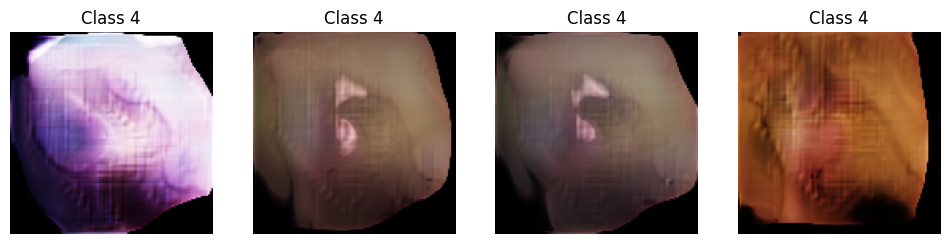

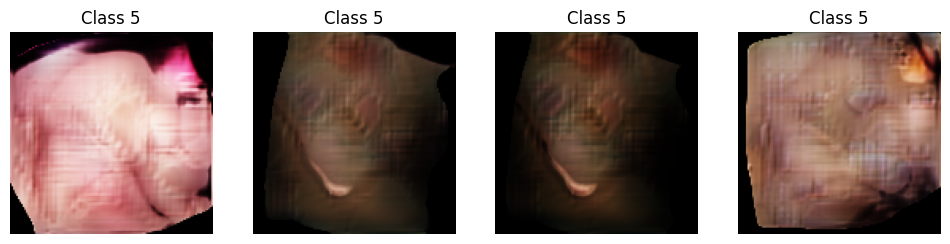

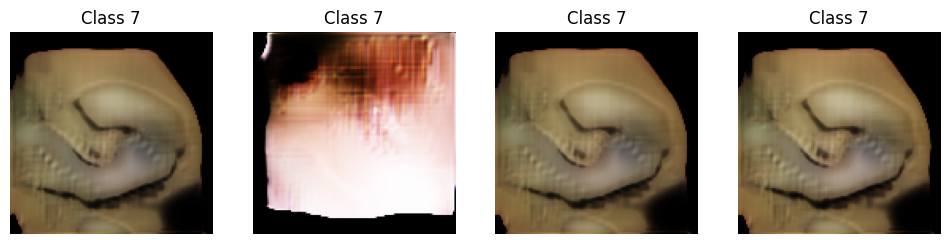

Combined dataset class distribution: Counter({6: 1651, 0: 1200, 1: 1200, 2: 1200, 3: 1200, 4: 1200, 5: 1200, 7: 1200})


In [ ]:
# Custom dataset class for synthetic images
class SyntheticDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx].transpose(1, 2, 0)
        image = Image.fromarray((image * 255).astype(np.uint8))
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

class_counts = Counter([label for _, label in train_dataset])
synthetic_images, synthetic_labels = generate_synthetic_images(generator, len(selected_classes), device, class_counts)
synthetic_dataset = SyntheticDataset(synthetic_images, synthetic_labels, transform=train_transforms)
combined_dataset = ConcatDataset([train_dataset, synthetic_dataset])

print(f"Combined dataset class distribution: {Counter([label for _, label in combined_dataset])}")

train_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True, num_workers=num_workers, pin_memory=True)


# **Define CNN Classifier Model**

In [ ]:
# CNN for classifying skin disease images
class SkinDiseaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)
# Calculate class weights to handle imbalanced classes
labels = [label for _, label in combined_dataset]
class_counts = Counter(labels)
# Assign higher weights to underrepresented classes
class_weights = [len(labels) / (len(selected_classes) * class_counts[i]) for i in range(len(selected_classes))]
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# **Train CNN Classifier**

In [ ]:
# Initialize the CNN classifier
model = SkinDiseaseClassifier(num_classes=len(selected_classes)).to(device)
# Use cross-entropy loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)
# Use AdamW optimizer with weight decay for regularization
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
# Reduce learning rate if validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
# Training the CNN
def train_cnn(model, train_loader, test_loader, criterion, optimizer, scheduler, device, epochs=50):
    best_loss = float('inf')
    patience = 15
    trigger = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= len(test_loader)
        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print("Early stopping triggered")
                break

    return model

model = train_cnn(model, train_loader, test_loader, criterion, optimizer, scheduler, device)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 1.4917, Train Acc: 0.4535, Val Loss: 1.5935, Val Acc: 0.4807
Epoch 2/50, Train Loss: 1.2219, Train Acc: 0.5499, Val Loss: 2.1060, Val Acc: 0.4850
Epoch 3/50, Train Loss: 1.1077, Train Acc: 0.5905, Val Loss: 1.3264, Val Acc: 0.5107
Epoch 4/50, Train Loss: 1.0249, Train Acc: 0.6212, Val Loss: 1.2338, Val Acc: 0.5579
Epoch 5/50, Train Loss: 0.9690, Train Acc: 0.6386, Val Loss: 1.2598, Val Acc: 0.5465
Epoch 6/50, Train Loss: 0.9253, Train Acc: 0.6597, Val Loss: 1.3920, Val Acc: 0.5536
Epoch 7/50, Train Loss: 0.9077, Train Acc: 0.6599, Val Loss: 1.2791, Val Acc: 0.5522
Epoch 8/50, Train Loss: 0.8614, Train Acc: 0.6780, Val Loss: 2.8461, Val Acc: 0.5594
Epoch 9/50, Train Loss: 0.8354, Train Acc: 0.6881, Val Loss: 1.6959, Val Acc: 0.5694
Epoch 10/50, Train Loss: 0.8137, Train Acc: 0.6914, Val Loss: 1.1852, Val Acc: 0.6252
Epoch 11/50, Train Loss: 0.7932, Train Acc: 0.7037, Val Loss: 1.3126, Val Acc: 0.5808
Epoch 12/50, Train Loss: 0.7650, Train Acc: 0.7122, Val Loss: 1

# **Test CNN and Visualize Confusion Matrix**

In [ ]:
# Evaluate the trained CNN on the test set
model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.7911


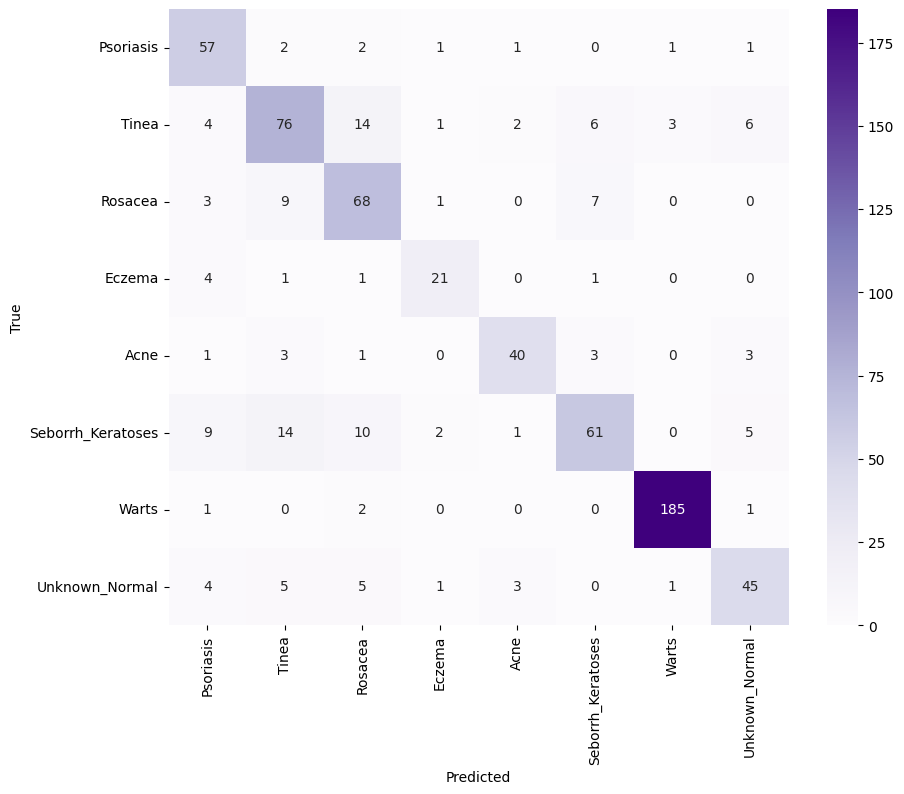

In [ ]:
# Create and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=selected_classes, yticklabels=selected_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()